In [1]:
import numpy as np
import matplotlib.pyplot as plt

from src.plot_style import configure_journal_style
from src.lifetime_kernels import build_survival_funcs_from_shifted_two_exp
from src.simulator import simulate_ensemble_N_grid
from src.transient_theory import compute_transient_pmf_and_moments
from src.utils import compute_gate_equilibrium_weights

# =============================
# Parameters (feel free to edit)
# =============================
Q = np.array([
    [-0.006, 0.005, 0.001],
    [ 0.050,-0.052, 0.002],
    [ 0.005, 0.002,-0.007],
], float)

lambdas = np.array([0.020, 0.003, 0.001], float)

L = 6000.0                                    # nt
W_means     = np.array([  5.0,  30.0, 240.0]) # s
v_means     = np.array([ 41.667, 33.333, 25.0]) # nt/s
Tterm_means = np.array([ 60.0,  60.0,  90.0]) # s

T_max = 1200.0
dt = 1.0
t_grid  = np.arange(0.0, T_max + dt, dt)   # edges
centers = 0.5 * (t_grid[:-1] + t_grid[1:])

# Build survival kernels (shifted two-exp, per arrival state)
H_funcs = build_survival_funcs_from_shifted_two_exp(
    L=L, W_means=W_means, v_means=v_means, Tterm_means=Tterm_means
)

# Stationary initial for the gate CTMC (or set your own pi0)
pi0 = compute_gate_equilibrium_weights(Q)


# =============================
# Theory (transient pmf over t)
# =============================
Nmax = 100
theory_out = compute_transient_pmf_and_moments(
    Q=Q, lambdas=lambdas, L=L,
    W_means=W_means, v_means=v_means, Tterm_means=Tterm_means,
    t_grid=t_grid, Nmax=Nmax, pi0=pi0
)

# Robustly extract p_nt (shape expected: (Nmax+1, len(t_grid)))
if isinstance(theory_out, dict):
    p_nt = np.asarray(theory_out.get("p_nt", theory_out.get("p_tn", None)), float)
else:
    # common tuple layout: (P, p_nt, mean_from_p, mean_vec, pi0_used, norm_err) or similar
    p_nt = np.asarray(theory_out[1], float)

# Align theory to centers by shifting one step: centers ~ (t_k, t_{k+1}]  -> use p_nt at t_{k+1}
p_nt_centers = p_nt[:, 1:]   # shape: (Nmax+1, len(centers))
n = np.arange(p_nt_centers.shape[0])[:, None]

mean_the = (n * p_nt_centers).sum(axis=0)
var_the  = ((n - mean_the) ** 2 * p_nt_centers).sum(axis=0)
noise_the = np.where(mean_the > 1e-12, var_the / (mean_the ** 2), np.nan)

# =============================
# Simulation (ensemble on grid)
# =============================
R = 200000
rng = np.random.default_rng(20251111)
N_mat = simulate_ensemble_N_grid(
    Q, lambdas, L, W_means, v_means, Tterm_means,
    T_max, edges=t_grid, R=R, pi0=pi0, rng=rng
)
# N_mat shape: (R, len(centers))

mean_emp  = N_mat.mean(axis=0)
# Use ddof=1 for an unbiased sample variance if you like; here population variance is fine for large R
var_emp   = N_mat.var(axis=0)
noise_emp = np.where(mean_emp > 1e-12, var_emp / (mean_emp ** 2), np.nan)




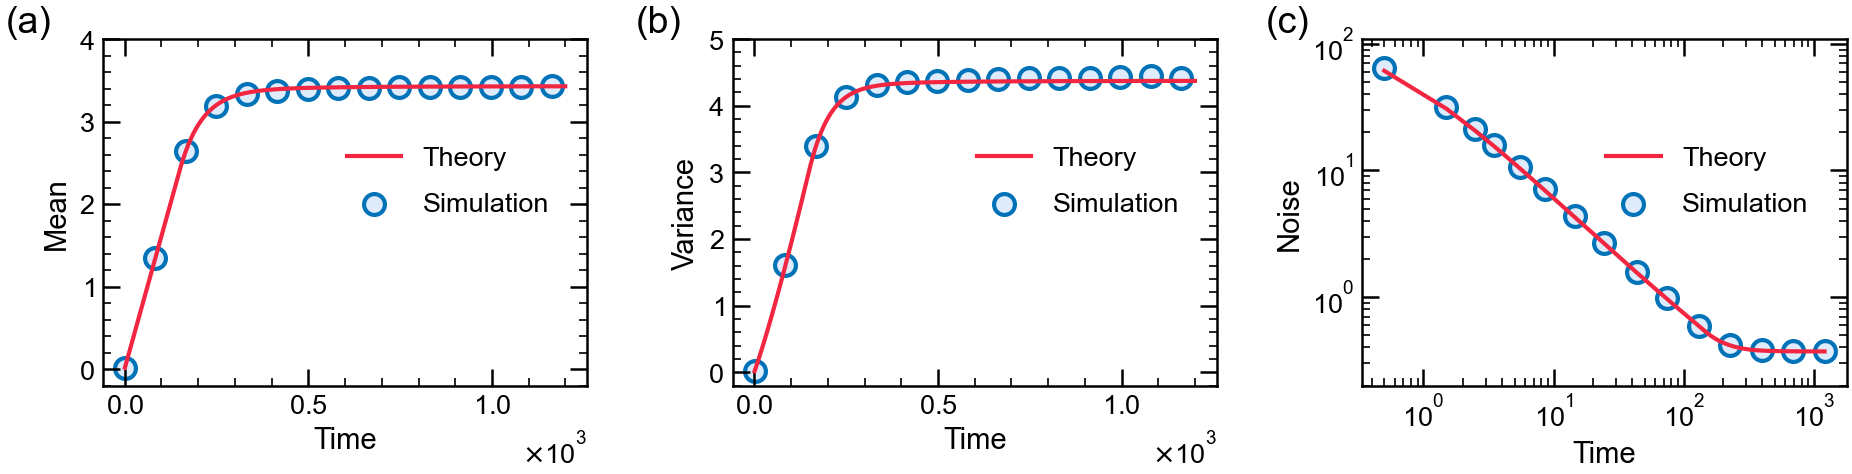

In [2]:
# =============================
# Plotting (3 separate figures)
# =============================
configure_journal_style()
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7.5, 1.5), dpi=300, sharex=False, sharey=False) 

# 1) Mean

ax1.plot(centers, mean_the, lw=1, label="Theory",color='#F32642')
ax1.scatter(centers[::83], mean_emp[::83],  lw=1, label="Simulation",edgecolors='#0072B8', facecolors='#DEEBFA', s=25)
ax1.set_xlabel("Time")
ax1.set_ylabel("Mean")
ax1.legend(labelspacing=0.8, loc='upper right', bbox_to_anchor=(1.00, 0.80))
ax1.set_ylim(-0.2, 4)

# 2) Variance
ax2.plot(centers, var_the, lw=1, label="Theory",color='#F32642')
ax2.scatter(centers[::83], var_emp[::83],  lw=1, label="Simulation",edgecolors='#0072B8', facecolors='#DEEBFA', s=25)

ax2.set_xlabel("Time")
ax2.set_ylabel("Variance")
ax2.legend(labelspacing=0.8, loc='upper right', bbox_to_anchor=(1.00, 0.80))
ax2.set_ylim(-0.2, 5)
# 3) Noise intensity = Var / Mean^2
x = np.asarray(centers)
y = np.asarray(noise_emp)


mask = x > 0
x_pos = x[mask]
y_pos = y[mask]


n_samples = 15
x_min, x_max = x_pos.min(), x_pos.max()
x_log_targets = np.logspace(np.log10(x_min), np.log10(x_max), n_samples)


idx = np.searchsorted(x_pos, x_log_targets)
idx = np.clip(idx, 0, len(x_pos)-1)


ax3.plot(centers, noise_the, lw=1, label="Theory",color='#F32642')
ax3.scatter(x_pos[idx], y_pos[idx],  lw=1, label="Simulation",edgecolors='#0072B8', facecolors='#DEEBFA', s=25)

ax3.set_xlabel("Time")
ax3.set_ylabel("Noise")
ax3.set_xscale('log')  
ax3.set_yscale('log')  
ax3.legend(labelspacing=0.8, loc='upper right', bbox_to_anchor=(1.00, 0.80))
ax3.set_ylim(0.2, 109)

plt.subplots_adjust(hspace=0.4, wspace=0.3)  


ax1.text(-0.2, 1.00, '(a)', transform=ax1.transAxes, fontsize=9, va='bottom', ha='left')
ax2.text(-0.2, 1.00, '(b)', transform=ax2.transAxes, fontsize=9, va='bottom', ha='left')
ax3.text(-0.2, 1.00, '(c)', transform=ax3.transAxes, fontsize=9, va='bottom', ha='left')
plt.savefig('Fig3.pdf', dpi=300, bbox_inches='tight')
plt.show()
